# Explore here

In [40]:
#los "imports"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer

from pickle import dump

In [41]:
#Importar la data a CSV
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
pd.read_csv(url).to_csv('../data/diabetes.csv', index=False)

In [42]:
#Cargamos el CSV y mostramos las primeras filas del DataFrame
df = pd.read_csv("../data/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [43]:
#Tamaño y dimensiones del DataFrame
df.shape

(768, 9)

In [44]:
#Resumen del DataFrame (estructura y tipo de datos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Todos los aspectos anteriores en la base de datos son aspectos que influyen al estudiar la diabetes.

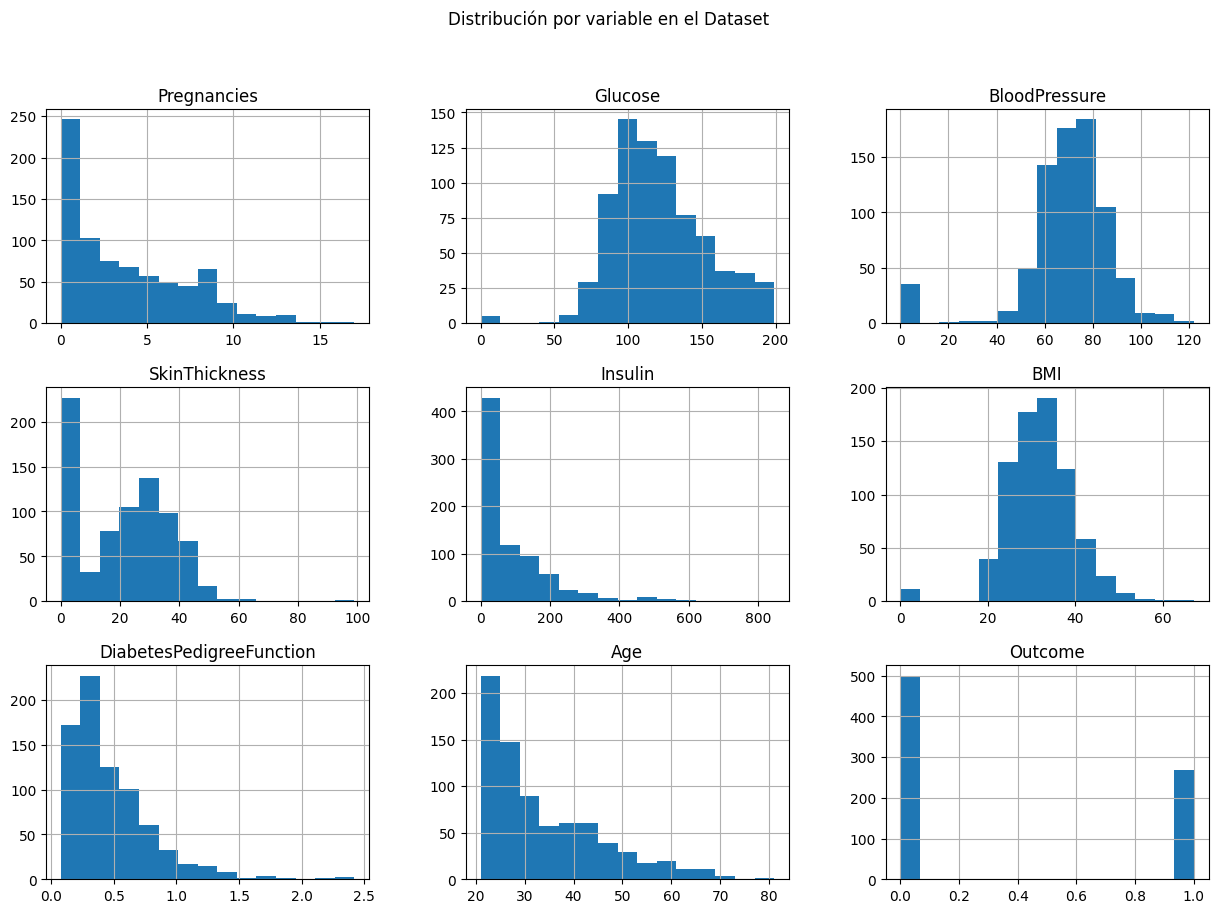

In [45]:
#Graficar cada una de las entradas anteriores, para ver cómo se comportan.
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribución por variable en el Dataset")
plt.show()

In [46]:
#Revisamos valores dentro del Dataset
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

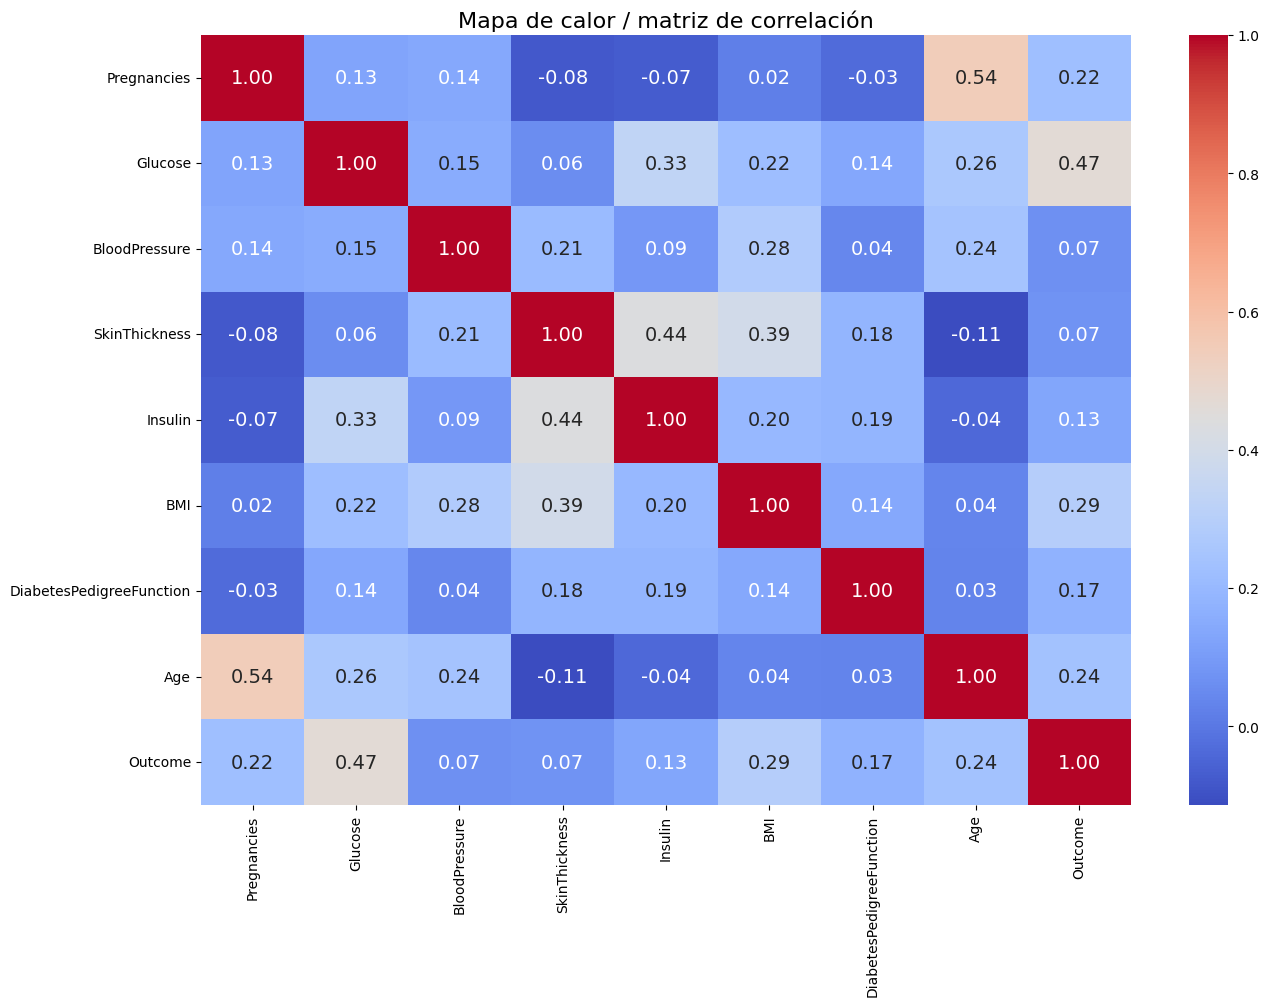

In [47]:
#Generamos un mapa de calor para poder visualizar la correlación entre ellos
corr = df[num_cols].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 14})
plt.title("Mapa de calor / matriz de correlación", fontsize=16)
plt.show()

Este mapa de calor muestra los datos tal cual aparecen en el Dataset, a continuación comencaremos a limpiar datos y a mejorar si es posible, para tener un mejor análisis.

In [48]:
#Los valores en 0 los remplazaremos, y utilizaremos la mediana para llenar esos espacios imaginando que los valores de la mediana son los "normales" entre los pacientes
cols_cero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_cero] = df[cols_cero].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")
df[cols_cero] = imputer.fit_transform(df[cols_cero])

En el punto anterior, dentro de los datos de glucosa, presión sanguinea, espesor de piel, etc. había datos en 0, que si cogemos una presión sanguinea de 0 es que el paciente está muerto, o una piel de 0 ml de grosor, por ende son erroneos, como dejo nota anterior, se elige la mediana para suplir los datos en 0.

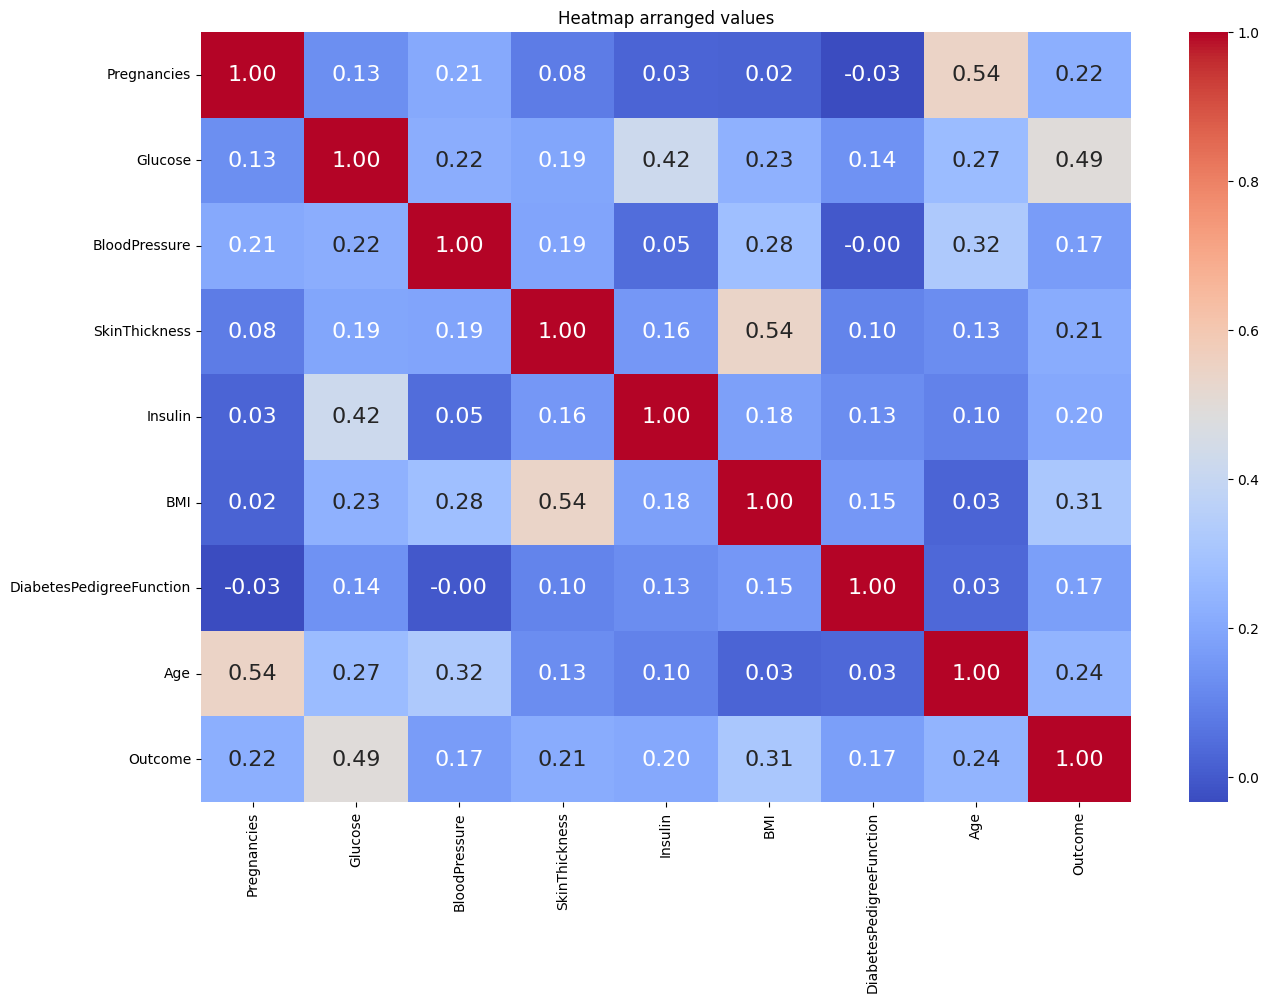

In [49]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 16})
plt.title("Heatmap arranged values")
plt.show()

Ahora hay datos que tienen mejor correlación...